In [70]:
# Assignment 3 - Visualization

# Dataset for visualization #1 from: https://data.ontario.ca/dataset/public-accounts-ministry-statements-and-schedules/resource/980335c3-57f6-44cd-96f5-51e2dc136458

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
on_data = pd.read_csv('/Users/Delta/DSI/visualization/02_activities/assignments/on-spend-data.csv')

on_data

,_id,Year,Amount $,Ministry Name,Expenditure Category (Operating / Capital),Program Name,Activity / Item,Sub Item,Standard Account (Expense/Asset Name),Account Details (Expense/Asset Details)
0,1,2024-25,4305992.0,Indigenous Affairs,Operating Expense,Indigenous Affairs Program,Ministry Administration,No Value,Salaries and wages,No Value
1,2,2024-25,752505.0,Indigenous Affairs,Operating Expense,Indigenous Affairs Program,Ministry Administration,No Value,Employee benefits,No Value
2,3,2024-25,136262.0,Indigenous Affairs,Operating Expense,Indigenous Affairs Program,Ministry Administration,No Value,Transportation and communication,No Value
3,4,2024-25,10068121.0,Indigenous Affairs,Operating Expense,Indigenous Affairs Program,Ministry Administration,No Value,Services,No Value
4,5,2024-25,72316.0,Indigenous Affairs,Operating Expense,Indigenous Affairs Program,Ministry Administration,No Value,Supplies and equipment,No Value
...,...,...,...,...,...,...,...,...,...,...
2330,2331,2024-25,14192492.0,Attorney General,Operating Expense,Alcohol and Gaming Commission of Ontario Program,Alcohol and Gaming Commission of Ontario,No Value,Services,No Value
2331,2332,2024-25,1079409.0,Attorney General,Operating Expense,Alcohol and Gaming Commission of Ontario Program,Alcohol and Gaming Commission of Ontario,No Value,Supplies and equipment,No Value
2332,2333,2024-25,-47584574.0,Attorney General,Operating Expense,Alcohol and Gaming Commission of Ontario Program,Alcohol and Gaming Commission of Ontario,No Value,Recoveries,No Value
2333,2334,2024-25,261.0,Attorney General,Capital Expense,Alcohol and Gaming Commission of Ontario Program,Alcohol and Gaming Commission of Ontario,No Value,Other transactions,No Value


In [5]:
on_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2335 entries, 0 to 2334
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   _id                                         2335 non-null   int64  
 1   Year                                        2335 non-null   object 
 2   Amount $                                    2335 non-null   float64
 3   Ministry Name                               2335 non-null   object 
 4   Expenditure Category (Operating / Capital)  2335 non-null   object 
 5   Program Name                                2335 non-null   object 
 6   Activity / Item                             2335 non-null   object 
 7   Sub Item                                    2335 non-null   object 
 8   Standard Account (Expense/Asset Name)       2335 non-null   object 
 9   Account Details (Expense/Asset Details)     2335 non-null   object 
dtypes: float64(1

In [12]:
aggregated = on_data.groupby('Program Name', as_index=False)['Amount $'].sum()
aggregated = aggregated.sort_values(by='Amount $', ascending=False)

print(aggregated)

                                   Program Name      Amount $
47                 Health Services and Programs  3.974349e+10
25   Elementary and Secondary Education Program  3.444215e+10
79             Ontario Health Insurance Program  2.956456e+10
12          Children and Adult Services Program  2.055613e+10
110                            Treasury Program  1.477609e+10
..                                          ...           ...
84                Pay Equity Commission Program  3.393936e+06
75    Office of the Lieutenant Governor Program  2.658571e+06
76                Office of the Premier Program  2.418231e+06
2      Agencies, Boards and Commissions Program  1.981629e+06
29       Emissions Performance Stanards Program  4.213430e+05

[112 rows x 2 columns]


In [68]:
top = aggregated.sort_values(by='Amount $', ascending=False).head(10)

print(top)

                                   Program Name      Amount $
47                 Health Services and Programs  3.974349e+10
25   Elementary and Secondary Education Program  3.444215e+10
79             Ontario Health Insurance Program  2.956456e+10
12          Children and Adult Services Program  2.055613e+10
110                            Treasury Program  1.477609e+10
106                                     Transit  1.276616e+10
64                 Long-Term Care Homes Program  8.388582e+09
90              Postsecondary Education Program  7.617695e+09
24         Electricity Price Mitigation Program  6.385418e+09
11          Child Care and Early Years Programs  5.038707e+09


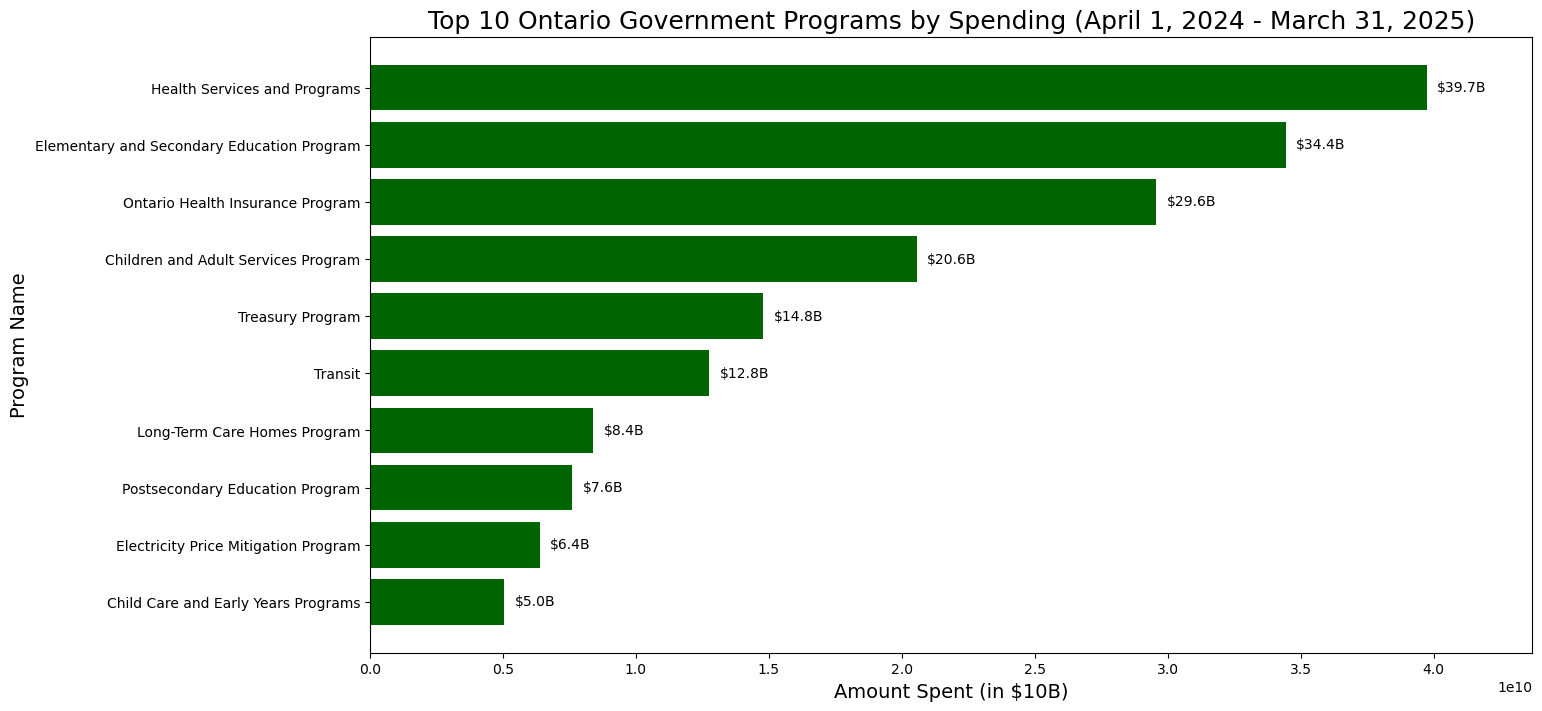

In [71]:
font1 = {'family':'sans-serif', 'size':14}
font2 = {'family':'sans-serif', 'size':18}

plt.figure(figsize=(15,8))
bars = plt.barh(top['Program Name'], top['Amount $'], color='darkgreen')

plt.xlabel('Amount Spent (in $10B)', fontdict = font1)
plt.ylabel('Program Name', fontdict = font1)
plt.title('Top 10 Ontario Government Programs by Spending (April 1, 2024 - March 31, 2025)', fontdict = font2)
plt.gca().invert_yaxis()  # so the highest appears at the top

# Add text labels to each bar
for bar in bars:
    width = bar.get_width()  
    plt.text(
        width + (0.01 * top['Amount $'].max()),  
        bar.get_y() + bar.get_height()/2,    
        f"${width/1e9:.1f}B",                      
        va='center',
        ha='left',
        fontsize=10
    )

plt.xlim(0, top5['Amount $'].max() * 1.1)

plt.show()

  > What software did you use to create your data visualization?
The first visualization was created using matplotlib in python.

    > Who is your intended audience? 
The intended audience for this figure was the average citizen in Ontario who may be interested in the direction of provincial government spending. This could be used by the government to convey important information to residents of Ontario about what programs are being funded the most by the provincial government.

    > What information or message are you trying to convey with your visualization? 
The aim of this visualization is to display top 10 Ontario government programs with the highest government spending allocated to them. 
    
    > What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots? 
This figure was meant to be very simple and straightforward, I wanted to eliminate any sort of clutter and to not have too complicated of a plot.
    
    > How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization? 
This visualization is easily reproducable as the data is publically accessible online, and the python code used to filter/transform the data can be used by anyone.

    > How did you ensure that your data visualization is accessible?  
This visualization is kept very simple and clear to ensure that it is most easily readable in a variety of different formats (online and in print).
    
    > Who are the individuals and communities who might be impacted by your visualization?  
For the most part, this visualization is aimed at informing residents of Ontario on government spending. This could be used as general information dissemination or potentially for political purposes as a way to campaign for increased spending in some areas or calls to cut spending in others.

    > How did you choose which features of your chosen dataset to include or exclude from your visualization? 
For this visualiation I decided to include only the top 5 highest funded programs by the government of Ontario. The goal here was to keep the information fairly simple and easy to understand without adding too much detail.

    > What ‘underwater labour’ contributed to your final data visualization product?
Since the data from this visualization comes from the official reports of the Ontario Government, there are many contributors to creating this dataset. This includes government workers at every level who are required to report on the spending, budgets, and expenses for each program and divisions within the program. All of this data also needs to be amalgamated by accounting professionals at a higher level before it can be publicly distributed.

VISUALIZATION 2 - TABLEAU

In [73]:
# Source for visualization 2: 
# https://data.ontario.ca/dataset/public-accounts-ministry-statements-and-schedules/resource/980335c3-57f6-44cd-96f5-51e2dc136458
# https://www.ontario.ca/page/public-accounts-ontario-2023-24#section-0

  > What software did you use to create your data visualization?
The second visualization was created using Tableau Public.

    > Who is your intended audience? 
This visualization is a comparison of the government spending by program between the 2023-2024 and 2024-2025 fiscal years. This figure was created with a more technical audience in mind, and could be used for internal government reporting and analysis. 

    > What information or message are you trying to convey with your visualization? 
This figure is showing a comparison of the changes in government spending from the two most recent fiscal years based on program.

    > What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots? 
Since this figure was meant to be a bit more analytical and demonstrate more detail, I wanted to include more data points here compared to the previous visualization. This included adding more programs to the list, and instead of limiting the figure to only the top 10 highest funded programs, expanding that range to any programs over the $1B cutoff. 

    > How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization? 
This visualization can be reproduced by extracting the publicly available datasets and plotting them using a stacked bar graph. Since there was no data manipulation involved, it would not be very difficult to reproduce these figures.

    > How did you ensure that your data visualization is accessible?  
In order to enhance accessibility, I used contrasting colours of orange and blue. In addition, the total amounts for each program funding by year were added to the end of each bar on the figure.

    > Who are the individuals and communities who might be impacted by your visualization?  
This figure could be used by internal government agencies when evaluating changes to government funding of programs, and identifying areas of need or overspending. It could also be used as a way to track how changes in spending lead to varying outcomes within the specific programs.

    > How did you choose which features of your chosen dataset to include or exclude from your visualization? 
I decided to include the programs with an annual funding that is greater than or equal to $1B.

    > What ‘underwater labour’ contributed to your final data visualization product?
Similar to the previous visualization, this visualization comes from the official reports of the Ontario Government and is the aggregate data of many branches and departmental agencies of the provincial government.